## Processing tidal gage data

### Import statements

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime
import seaborn as sns

In [73]:
gage = pd.read_csv('usgs_data_hre.txt', sep='\t', header=24)
gage = gage.drop(0)
gage['datetime'] = pd.to_datetime(gage['datetime'], format='%Y-%m-%d %H:%M')
gage['218558_00065'] = pd.to_numeric(gage['218558_00065'], errors='coerce')
gage['66254_00065'] = pd.to_numeric(gage['66254_00065'], errors='coerce')
gage.rename(columns={'218558_00065':'Ocean side', '66254_00065':'River side'}, inplace=True)

gage = gage[['datetime','Ocean side','River side']]

start_date = datetime(2022, 7, 14, 18, 0, 0, 0)
end_date = datetime(2022, 7, 15, 6, 0, 0, 0)
gage = gage[(gage['datetime'] > start_date) & (gage['datetime'] < end_date)]

gage['head'] = gage['River side'] - gage['Ocean side']
gage_scaled = pd.DataFrame({'datetime':gage['datetime'],'Ocean side':gage['Ocean side']/3.05, 'River side':gage['River side']/3.05, 'Head':gage['head']/3.05})
gage_scaled['Ocean side'] = gage_scaled['Ocean side']*0.3048 # convert to m
gage_scaled['River side'] = gage_scaled['River side']*0.3048
gage_scaled['Head'] = gage_scaled['Head']*0.3048

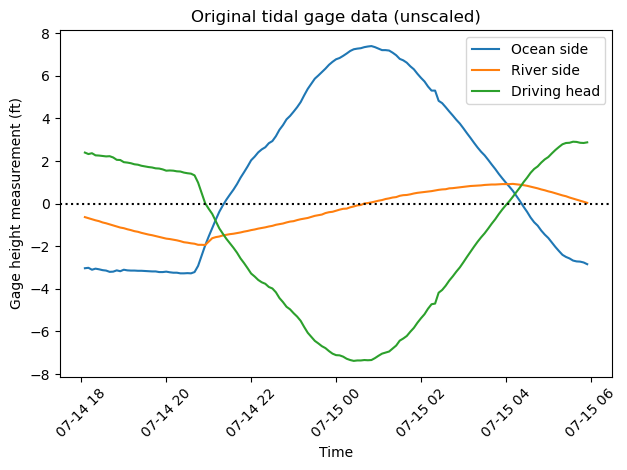

In [74]:
sns.lineplot(x='datetime', y='Ocean side', data=gage, label='Ocean side')
sns.lineplot(x='datetime', y='River side', data=gage, label='River side')
sns.lineplot(x='datetime', y='head', data=gage, label='Driving head')
plt.axhline(0, linestyle=':', color='black')

plt.title('Original tidal gage data (unscaled)')
plt.xlabel('Time')
plt.ylabel('Gage height measurement (ft)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

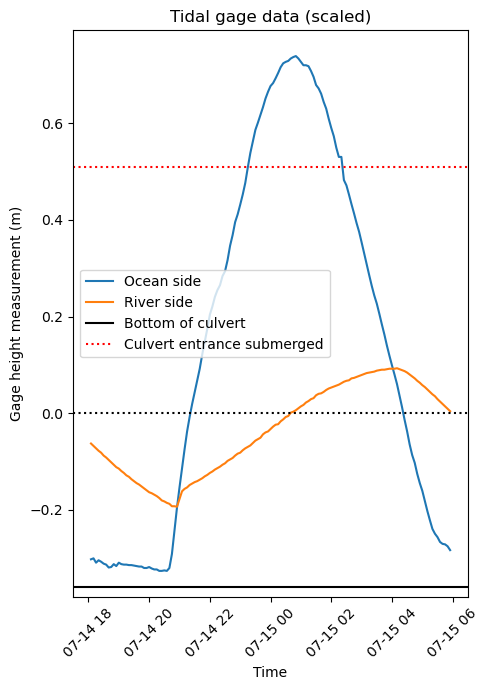

In [115]:
plt.figure(figsize=(5,7))

sns.lineplot(x='datetime', y='Ocean side', data=gage_scaled, label='Ocean side')
sns.lineplot(x='datetime', y='River side', data=gage_scaled, label='River side')
#sns.lineplot(x='datetime', y='Head', data=gage_scaled, label='Driving head')
plt.axhline(0, linestyle=':', color='black')

plt.axhline(0.51-0.87, color='black', label='Bottom of culvert')
plt.axhline(0.51, linestyle=':', color='red', label='Culvert entrance submerged')

plt.title('Tidal gage data (scaled)')
plt.xlabel('Time')
plt.ylabel('Gage height measurement (m)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [114]:
# Find indices and associated values for Ocean side + 0.36 closest to targets on either side of the peak
half_cut = datetime(2022,7,15,0)
targets = [0.4, 0.6, 0.8, 1]
results = []
for target in targets:
    # Before peak
    before = gage_scaled[gage_scaled['datetime'] < half_cut].copy()
    idx_before = (before['Ocean side'] + 0.36 - target).abs().idxmin()
    results.append({
        'Datetime': gage_scaled.loc[idx_before, 'datetime'],
        'Ocean pts': gage_scaled.loc[idx_before, 'Ocean side'] + 0.36,
        'River pts': gage_scaled.loc[idx_before, 'River side'] + 0.36,
        'Side': 'before'
    })
    # After peak
    after = gage_scaled[gage_scaled['datetime'] > half_cut].copy()
    idx_after = (after['Ocean side'] + 0.36 - target).abs().idxmin()
    results.append({
        'Datetime': gage_scaled.loc[idx_after, 'datetime'],
        'Ocean pts': gage_scaled.loc[idx_after, 'Ocean side'] + 0.36,
        'River pts': gage_scaled.loc[idx_after, 'River side'] + 0.36,
        'Side': 'after'
    })
trial_data = pd.DataFrame(results)
trial_data = trial_data.drop(1)
trial_data = trial_data.sort_values(by='Datetime')
display(trial_data)

,Datetime,Ocean pts,River pts,Side
0,2022-07-14 21:30:00,0.402972,0.217094,before
2,2022-07-14 22:10:00,0.600842,0.243077,before
4,2022-07-14 23:00:00,0.791717,0.278054,before
6,2022-07-14 23:45:00,0.993584,0.316029,before
7,2022-07-15 01:45:00,1.004577,0.403971,after
5,2022-07-15 02:40:00,0.792716,0.431953,after
3,2022-07-15 03:25:00,0.603840,0.445944,after


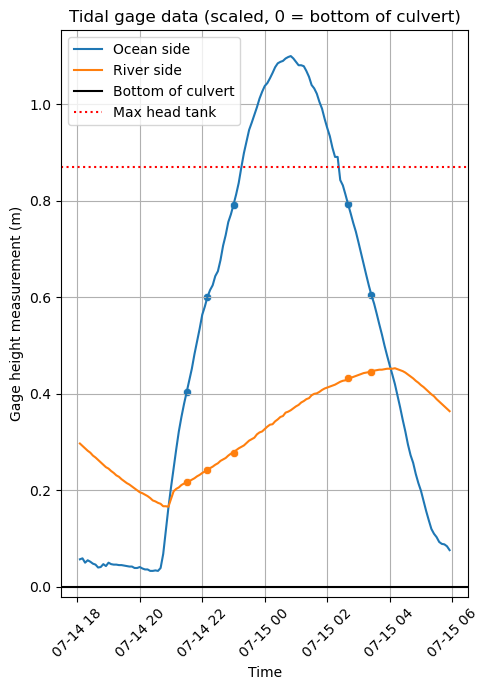

In [111]:
# create plot with culvert top and bottom, showing height relative to the bottom of the culvert.

plt.figure(figsize=(5,7))

plt.plot(gage_scaled['datetime'], gage_scaled['Ocean side']+0.36, label='Ocean side')
plt.plot(gage_scaled['datetime'], gage_scaled['River side']+0.36, label='River side')
sns.scatterplot(x='Datetime', y='Ocean pts', data=trial_data)
sns.scatterplot(x='Datetime', y='River pts', data=trial_data)
#sns.lineplot(x='datetime', y='Head', data=gage_scaled, label='Driving head')

plt.axhline(0, color='black', label='Bottom of culvert')
plt.axhline(0.51+0.36, linestyle=':', color='red', label='Max head tank')

plt.title('Tidal gage data (scaled, 0 = bottom of culvert)')
plt.xlabel('Time')
plt.ylabel('Gage height measurement (m)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()